In [152]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [153]:
# Data read
df = pd.read_csv('/content/gallbladder_cancer_dataset.csv')
df.head(5)

,Patient_ID,Age,Gender,BMI,Ethnicity,Smoking_History,Alcohol_Consumption,Family_History,Diabetes,Gallstones,Abdominal_Pain,Jaundice,Weight_Loss,Tumor_Size,Lymph_Node_Involvement,Stage,CEA_Level,CA19-9_Level,Treatment_Type,Survival_Months,Outcome
0,PID_1,68,Female,27.7,Hispanic,Yes,No,Yes,Yes,No,Yes,Yes,0.4,2.9,No,II,8.48,228.94,Chemotherapy,23,Deceased
1,PID_2,81,Female,37.3,Asian,No,No,No,Yes,No,No,Yes,7.2,8.8,No,II,17.96,121.62,Chemotherapy,33,Deceased
2,PID_3,58,Male,27.5,African,Yes,Yes,Yes,No,No,No,No,5.4,9.5,No,III,3.67,363.39,Chemotherapy,52,Deceased
3,PID_4,44,Female,28.4,Caucasian,Yes,Yes,Yes,Yes,Yes,No,Yes,5.1,5.7,Yes,III,19.91,255.43,Chemotherapy,47,Deceased
4,PID_5,72,Male,39.8,Caucasian,No,Yes,No,Yes,No,Yes,No,2.4,4.2,No,IV,2.82,506.69,Chemotherapy,18,Deceased


In [154]:
df = df.drop(columns=['Patient_ID'])
df.head(5)
for col in df.select_dtypes(include='object').columns:
  df[col] = LabelEncoder().fit_transform(df[col])
df.head(5)

,Age,Gender,BMI,Ethnicity,Smoking_History,Alcohol_Consumption,Family_History,Diabetes,Gallstones,Abdominal_Pain,Jaundice,Weight_Loss,Tumor_Size,Lymph_Node_Involvement,Stage,CEA_Level,CA19-9_Level,Treatment_Type,Survival_Months,Outcome
0,68,0,27.7,3,1,0,1,1,0,1,1,0.4,2.9,0,1,8.48,228.94,0,23,1
1,81,0,37.3,1,0,0,0,1,0,0,1,7.2,8.8,0,1,17.96,121.62,0,33,1
2,58,1,27.5,0,1,1,1,0,0,0,0,5.4,9.5,0,2,3.67,363.39,0,52,1
3,44,0,28.4,2,1,1,1,1,1,0,1,5.1,5.7,1,2,19.91,255.43,0,47,1
4,72,1,39.8,2,0,1,0,1,0,1,0,2.4,4.2,0,3,2.82,506.69,0,18,1


In [155]:
df_correlated = df.corrwith(df['Outcome'], axis=0, method='pearson')
print(df_correlated.sort_values())

Stage                    -0.046651
Smoking_History          -0.040781
Treatment_Type           -0.037126
Weight_Loss              -0.028919
BMI                      -0.026574
Gender                   -0.018508
Abdominal_Pain           -0.010910
Survival_Months          -0.007919
Diabetes                  0.002768
Tumor_Size                0.003341
Ethnicity                 0.005731
Jaundice                  0.020528
CEA_Level                 0.022832
CA19-9_Level              0.026781
Alcohol_Consumption       0.029230
Age                       0.031720
Family_History            0.046253
Lymph_Node_Involvement    0.073041
Gallstones                0.089968
Outcome                   1.000000
dtype: float64


In [156]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train.shape, X_test.shape

((700, 19), (300, 19))

In [157]:
model = XGBClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [158]:
print(f"Aniqlilik: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

Aniqlilik: 0.5133333333333333
              precision    recall  f1-score   support

           0       0.41      0.38      0.40       125
           1       0.58      0.61      0.59       175

    accuracy                           0.51       300
   macro avg       0.49      0.49      0.49       300
weighted avg       0.51      0.51      0.51       300



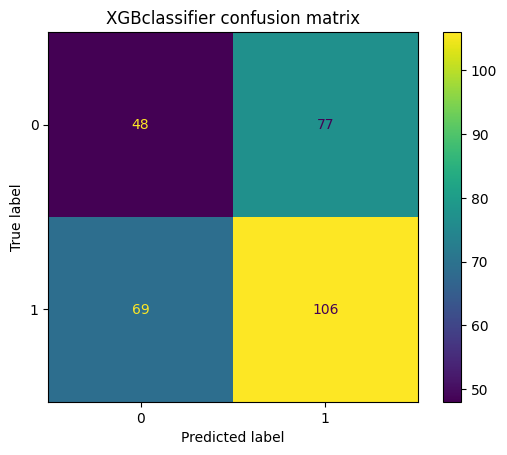

In [159]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=model.classes_)
disp.plot()
plt.title("XGBclassifier confusion matrix")
plt.show()

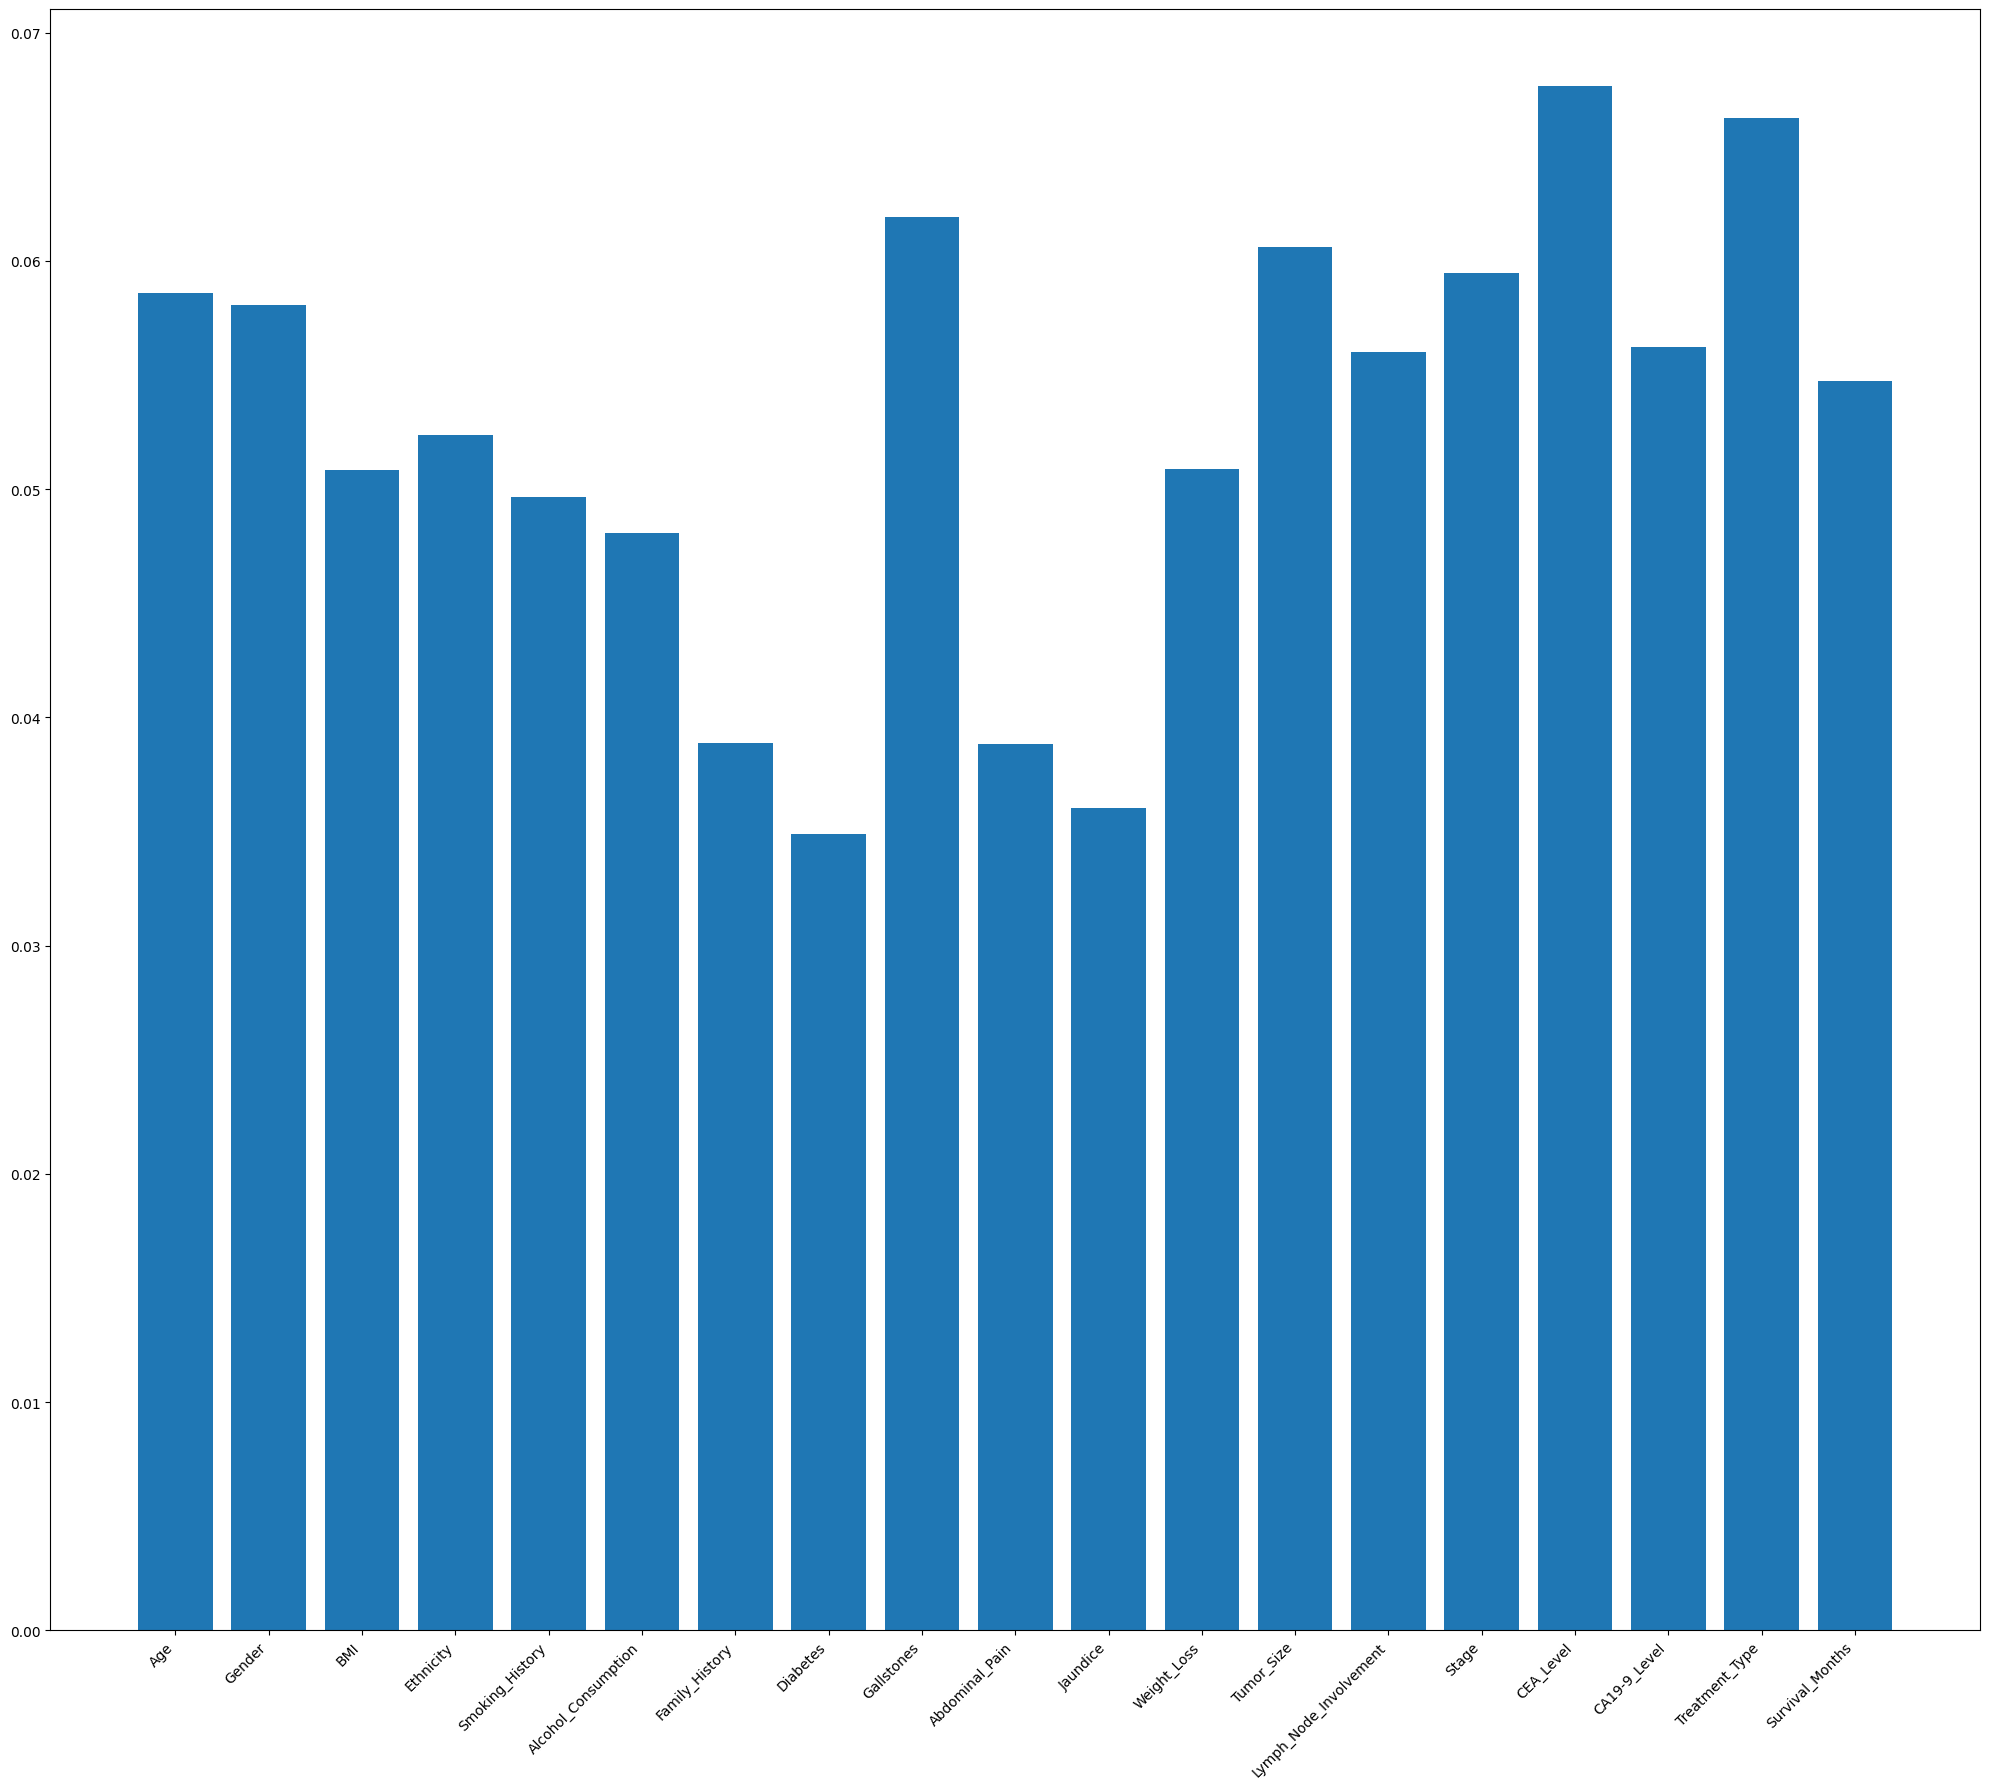

In [160]:
# Feature importance

plt.figure(figsize=(20, 18))
plt.bar(range(len(X.columns)), model.feature_importances_)
plt.xticks(range(len(X.columns)), X.columns, rotation=45, ha='right')
plt.tight_layout()
plt.show()